# CVAI Exercise: Canny Edge Detector

##  Canny Edge Detector

Edges in an image can be detected using the Canny edge detector. John F. Canny, an Australian computer scientist, invented this method in 1986. The method implements edge detection as solution of an optimization problem and consists of three steps:

- computation of the edges' strength using a differential operator
- finding local maxima of strength perpendicular to edge direction
- connecting edge pixels using hysteresis thresholding with 2 threshold values

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as pl
import cv2 as cv

path = '/exchange/cvai/images/'

## Image

(800, 600) 0 253


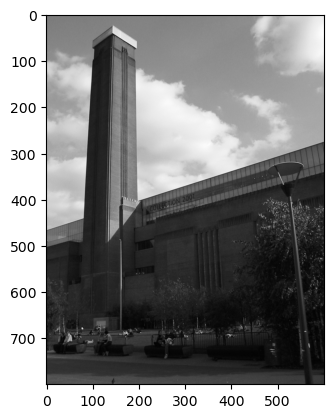

In [2]:
image  = cv.cvtColor (cv.imread (path + 'LondonSmall.png'), cv.COLOR_BGR2GRAY)
print (image.shape, np.min (image), np.max (image))
pl.imshow (image, cmap = 'gray')

## Exercise 1: Edge Detection

- Detect the edges in the image above using the canny edge detector in OpenCV.
- How does the result depend on the choice of the parameters?

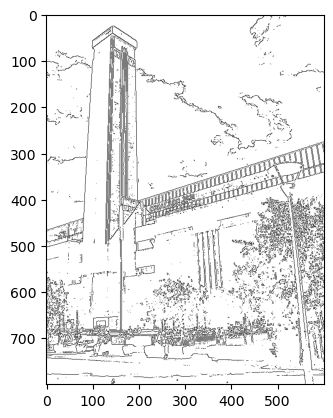

In [17]:
canny = cv.Canny(image, 50, 50)

pl.imshow (0xFF - canny, cmap = 'gray')
# pl.imshow (canny, cmap = 'gray')

In [18]:
assert canny is not None

## Exercise 2:  Canny Filter for Different Resolutions

The `Canny` filter implemented in OpenCV has only a few parameters, particularly it is impossible to apply it to different resolutions directly. As workaround we compute the edges in advance and submit them to the canny operator:

- Blur the image
- Compute the edges of the blurred image
- Compute the Canny operator directly on the edges

### Blur the image

using `GaussianBlur`

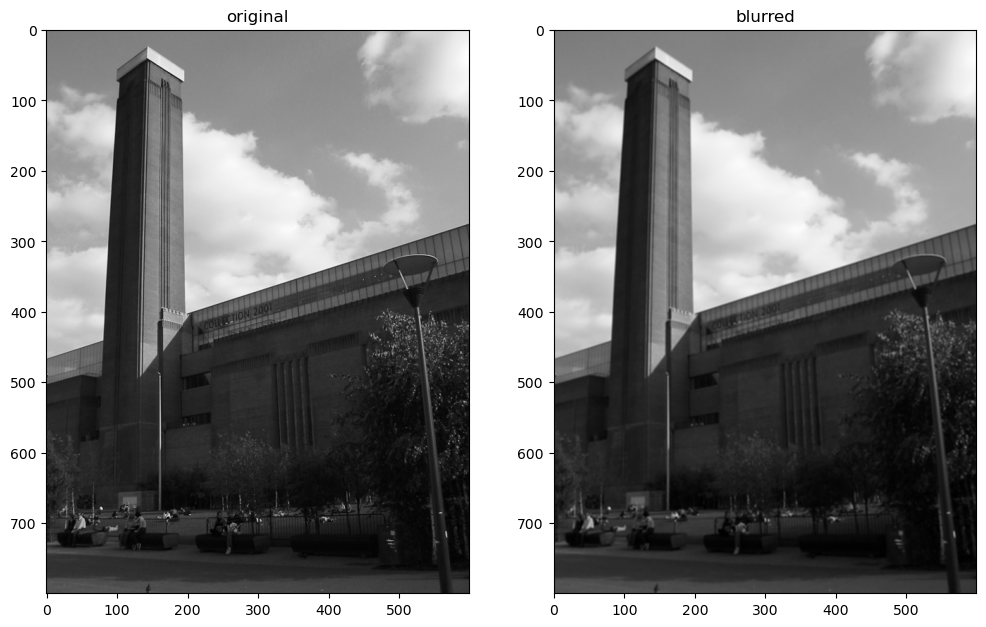

In [34]:
blurred = cv.blur(image,(3,3))


pl.figure (figsize = (12, 8))

pl.subplot (1, 2, 1)
pl.title ('original')
pl.imshow (image, cmap = 'gray')

pl.subplot (1, 2, 2)
pl.title ('blurred')
pl.imshow (blurred, cmap = 'gray')

In [35]:
assert blurred is not None

### Compute the edges

- The first partial derivatives of the image, $\text{dx}$ and $\text{dy}$, can be computed using the `Sobel` operator.
- Compute the strength of the edges: $\text{edge}=\sqrt{\text{dx}^2 + \text{dy}^2}$.
- Display the results of the derivatives and the strength of the edges in an adequate form.

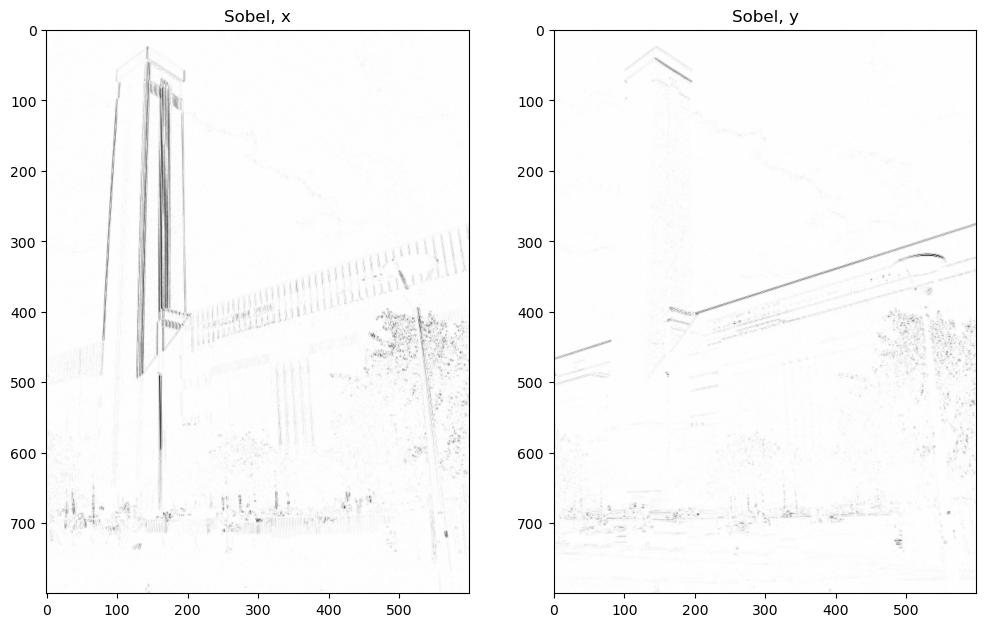

In [61]:
dx = cv.Sobel(image, cv.CV_64F, 2, 0, ksize=3)
dy = cv.Sobel(image, cv.CV_64F, 0, 2, ksize=3)

pl.figure (figsize = (12, 8))

pl.subplot (1, 2, 1)
pl.title ('Sobel, x')
pl.imshow (255 - np.abs (dx), cmap = 'gray')

pl.subplot (1, 2, 2)
pl.title ('Sobel, y')
pl.imshow (255 - np.abs (dy), cmap = 'gray')

In [62]:
assert dx is not None
assert dy is not None

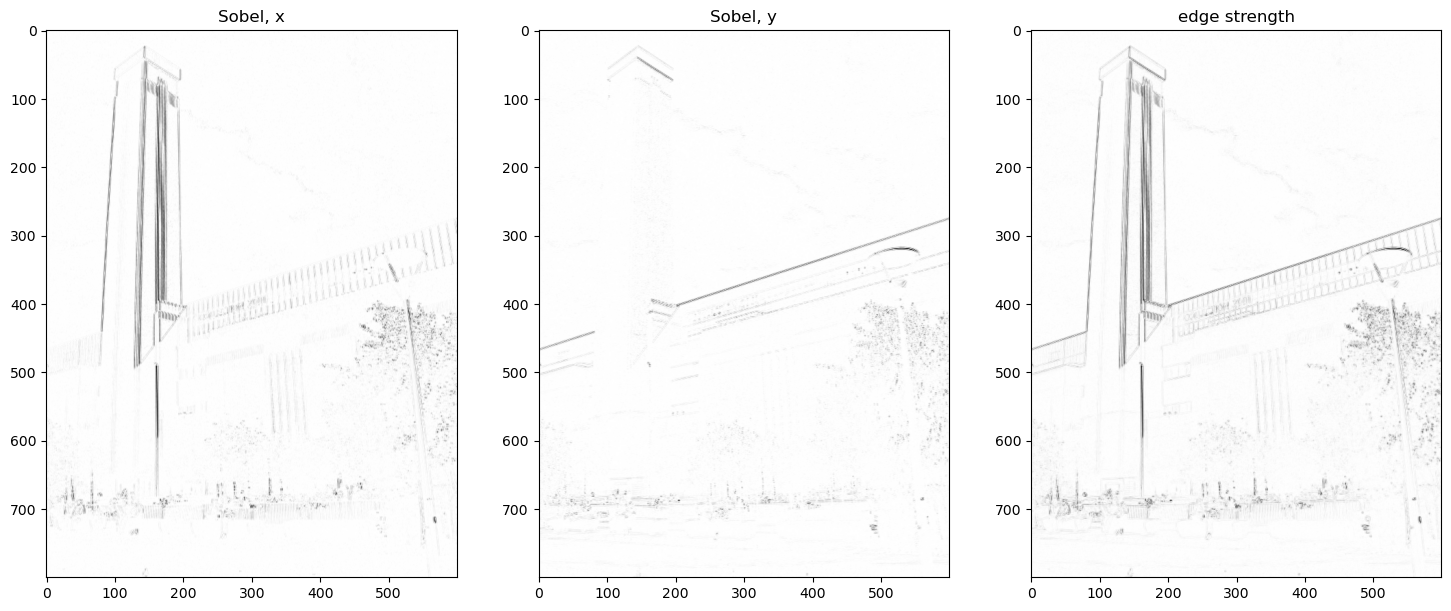

In [63]:
edge = np.sqrt(dx**2 + dy**2)

pl.figure (figsize = (18, 8))

pl.subplot (1, 3, 1)
pl.title ('Sobel, x')
pl.imshow (255 - np.abs (dx), cmap = 'gray')

pl.subplot (1, 3, 2)
pl.title ('Sobel, y')
pl.imshow (255 - np.abs (dy), cmap = 'gray')

pl.subplot (1, 3, 3)
pl.title ('edge strength')
pl.imshow (255 - edge / np.max (edge), cmap = 'gray')

In [64]:
assert edge is not None

### Compute Canny again

- Apply the Canny operator to the edges (partial derivatives in x and y direction).
- Hint: The arguments have to be 16 bit signed integers.
- How are the edges affected by the $\sigma$ of the Gaussian blur?

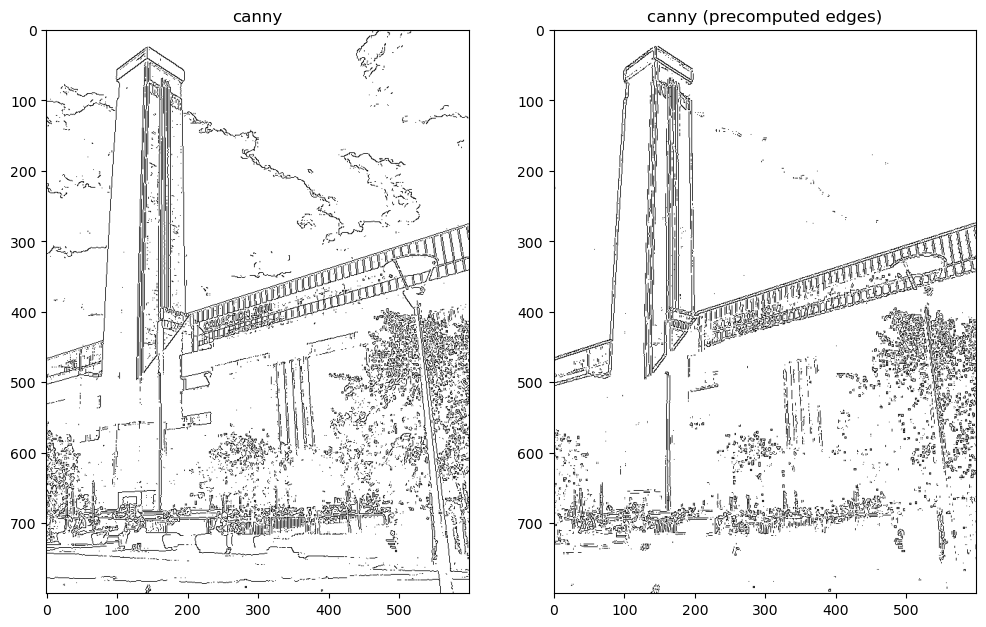

In [68]:
edge = (edge / np.max(edge) * 255).astype(np.uint8)  # Normalize to 8-bit

canny2 = cv.Canny(edge, 50, 50)

pl.figure (figsize = (12, 8))

pl.subplot (1, 2, 1)
pl.title('canny')
pl.imshow (255 - canny, cmap = 'gray')

pl.subplot (1, 2, 2)
pl.title('canny (precomputed edges)')
pl.imshow (255 - canny2, cmap = 'gray')

In [69]:
assert canny2 is not None